In [21]:
!ls

01_data_format.ipynb  03_map_stat.ipynb		  final.ipynb
02_predicted.ipynb    directory_file_counts.xlsx


In [26]:
import os

# Путь к основной директории
base_directory = '../output_excel'

# Вывод в формате Markdown-таблицы
print('| Директория | Файлы |')
print('|------------|-------|')

for dirpath, dirnames, filenames in os.walk(base_directory):
    # Пропустить саму базовую директорию
    if dirpath == base_directory:
        continue
    # Проверить, что директория содержит файлы
    if filenames:
        directory_name = os.path.basename(dirpath)
        file_list = [os.path.splitext(f)[0]
                     for f in filenames if not f.startswith('.')]
        file_list_str = '<br>'.join(file_list)
        print(f'| {directory_name} | {file_list_str} |')

| Директория | Файлы |
|------------|-------|
| А-289_Краснодар_-_Славянск-на-Кубани_-_Темрюк | км_37+338_а_д_А-289_Краснодар_-_Темрюк<br>км_7+350_а_д_А-289_Краснодар_-_Темрюк<br>км_69+370_а_д_А-289_Краснодар_-_Темрюк |
| А-146_Краснодар_-_Новороссийск_-_Верхнебаканский | км_130+810_а_д_А-146_Краснодар-Верхнебаканский<br>км_53+800_а_д_А-146_Краснодар-Верхнебаканский<br>км_32+000_а_д_А-146_Краснодар-Верхнебаканский |
| А-160_Майкоп_-_Усть-Лабинск_-_Кореновск | км_58+990_а_д_А-160_Майкоп-Кореновск |
| А-290_Новороссийск_-_Керченский_пролив_-_Керчь | км_28+500_а_д_А-290_Новороссийск-Керчь<br>км_10+200_а_д_А-290_Новороссийск-Керчь |
| 03_ОП_РЗ_03К-001_г.Краснодар_-_г.Ейск | км_47+243_а_д_г.Краснодар_-_г.Ейск |
| М-4_Дон_Москва_–_Воронеж_–_Ростов-на-Дону_–_Краснодар_–_Новороссийск | Обработано__км_1301+500_а_д_М-4_Дон_Москва_–_Новороссийск<br>Обработано__км_1278+575_а_д_М-4_Дон_Москва_–_Новороссийск<br>Обработано__км_1389+000_а_д_М-4_Дон_Москва_–_Новороссийск<br>км_1389+000_а_д_М-4_Дон_Моск

In [37]:
import os

# Путь к основной директории
base_directory = '../output_excel'

# Список всех файлов рекурсивно с обработкой имени и формированием ссылки
print('Название файла, Км, Ссылка')

for dirpath, dirnames, filenames in os.walk(base_directory):
    for f in filenames:
        if not f.startswith('.') and not f.startswith('Обработано__'):
            filename_without_ext = os.path.splitext(f)[0]
            # Убираем префикс "км_37+338" и сохраняем оставшееся имя и "км_37"
            # ожидаем формат км_37+338_остальное
            parts = filename_without_ext.split('_', 2)
            if len(parts) == 3:
                km_value = parts[1].split('+')[0]  # "37" из "37+338"
                remaining_name = parts[2].replace('а_д_', '')
                # Формируем ссылку с заменой параметров
                link = f'https://yandex.ru/maps/org/{remaining_name}/240216916417/?indoorLevel=2&ll=29.125243%2C40.994035&mode=search&sctx=ZAAAAAgBEAAaKAoSCc9nQL0ZM0NAEYPfhhivpUZAEhIJg%2Fbq46Hv8j8Rai43GOow4D8iBgABAgMEBSgKOABAz4cGSAFqAnJ1nQHNzMw9oAEAqAEAvQFE8RaFwgEGwYOt8P4GggIHZGFzZGFzZIoCAJICAJoCDGRlc2t0b3AtbWFwcw%3D%3D&sll=29.125243%2C40.994035&sspn=0.018492%2C0.008487&text={remaining_name}_{km_value}&z=16.7'
                print(f'{remaining_name}, км_{km_value}, {link}')

Название файла, Км, Ссылка
А-289_Краснодар_-_Темрюк, км_37, https://yandex.ru/maps/org/А-289_Краснодар_-_Темрюк/240216916417/?indoorLevel=2&ll=29.125243%2C40.994035&mode=search&sctx=ZAAAAAgBEAAaKAoSCc9nQL0ZM0NAEYPfhhivpUZAEhIJg%2Fbq46Hv8j8Rai43GOow4D8iBgABAgMEBSgKOABAz4cGSAFqAnJ1nQHNzMw9oAEAqAEAvQFE8RaFwgEGwYOt8P4GggIHZGFzZGFzZIoCAJICAJoCDGRlc2t0b3AtbWFwcw%3D%3D&sll=29.125243%2C40.994035&sspn=0.018492%2C0.008487&text=А-289_Краснодар_-_Темрюк_37&z=16.7
А-289_Краснодар_-_Темрюк, км_7, https://yandex.ru/maps/org/А-289_Краснодар_-_Темрюк/240216916417/?indoorLevel=2&ll=29.125243%2C40.994035&mode=search&sctx=ZAAAAAgBEAAaKAoSCc9nQL0ZM0NAEYPfhhivpUZAEhIJg%2Fbq46Hv8j8Rai43GOow4D8iBgABAgMEBSgKOABAz4cGSAFqAnJ1nQHNzMw9oAEAqAEAvQFE8RaFwgEGwYOt8P4GggIHZGFzZGFzZIoCAJICAJoCDGRlc2t0b3AtbWFwcw%3D%3D&sll=29.125243%2C40.994035&sspn=0.018492%2C0.008487&text=А-289_Краснодар_-_Темрюк_7&z=16.7
А-289_Краснодар_-_Темрюк, км_69, https://yandex.ru/maps/org/А-289_Краснодар_-_Темрюк/240216916417/?indoorLevel=2&ll=2

In [52]:
cords = [
'45.268452, 38.439297',
'45.082509, 38.697590',
'45.212152, 38.117772',
'44.873245, 37.758868',
'44.850916, 38.606348',
'44.889199, 38.829624',
'45.023641, 39.687345',
'44.901528, 37.575477',
'44.783831, 37.680122',
# '46.667505, 38.304550',
'44.633296, 39.098059',
'45.486758, 39.411652',
'44.365995, 38.687978',
'44.431056, 38.780585',
'45.316818, 39.245131',
'44.326512, 38.697410',
'44.901024, 39.802455',
'44.757384, 38.996001',
'45.095357, 38.992156',
'45.150902, 39.059970',
'44.711127, 39.216250',
'45.105816, 39.387730',
'45.243504, 39.681937',
]

In [41]:
!pip install contextily

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 KB 778.2 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.4/90.4 KB 1.4 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 3.9 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 KB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 KB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 KB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 KB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 KB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 KB 2.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.7/128.7 KB 4.9 MB/s eta 0:00:00
You should consider upgrading via the '/home/nick/transportation/venv/bin/python3 -m pip install --upgrade pip' command.


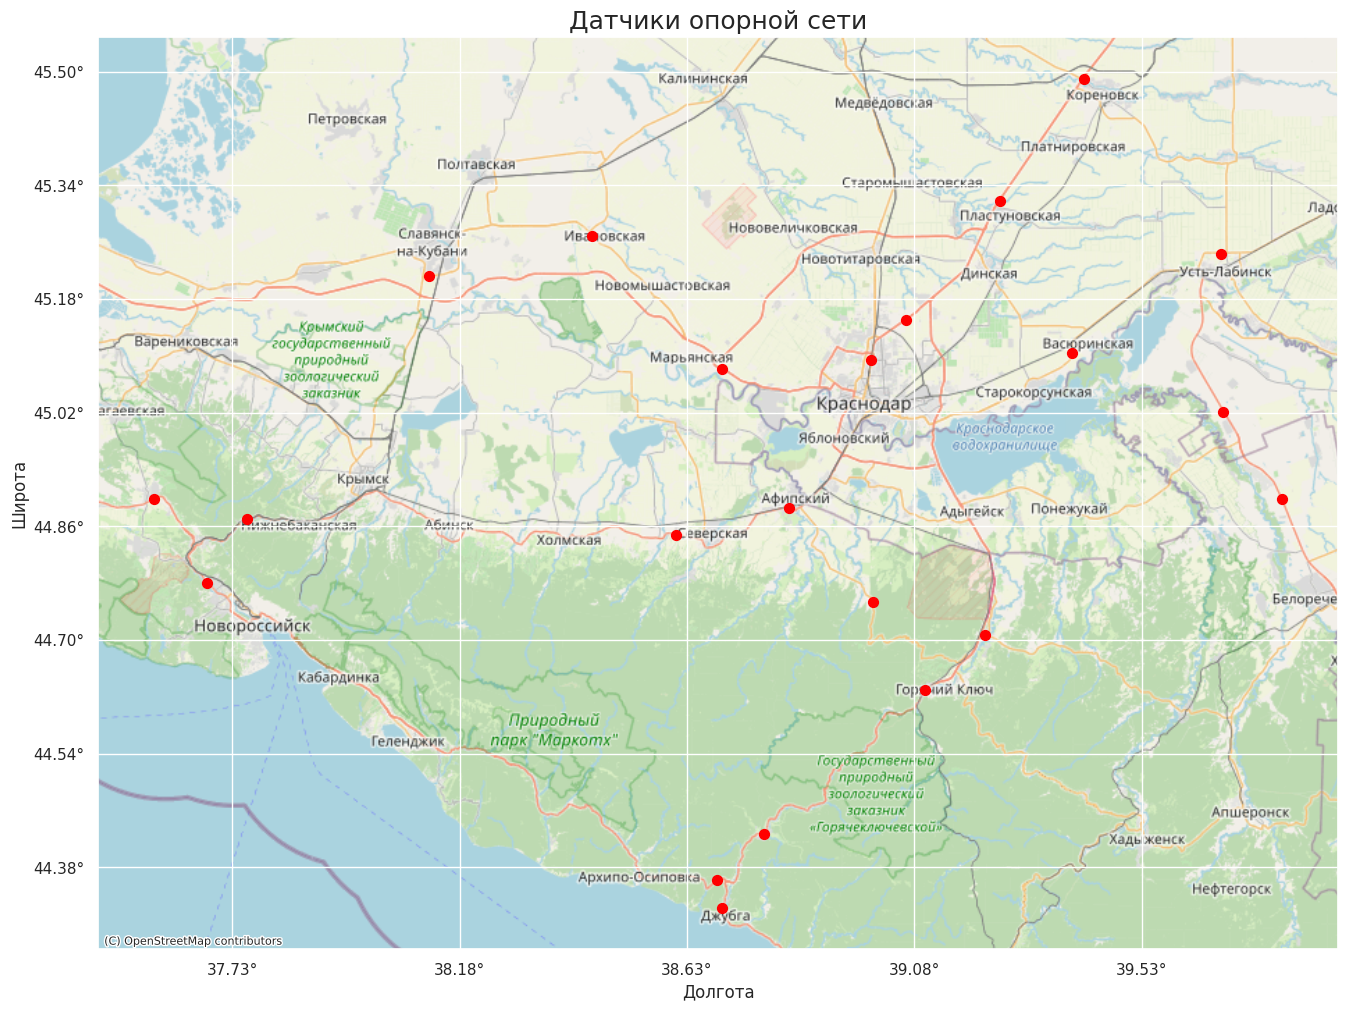

In [54]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import pyproj

sns.set_theme()

# Ваши координаты в GeoDataFrame
points = [Point(float(lon), float(lat))
          for lat, lon in (coord.split(', ') for coord in cords)]
gdf = gpd.GeoDataFrame(geometry=points, crs='EPSG:4326')  # WGS84 (градусы)

# Сохраняем оригинальные координаты для подписей осей
gdf_orig = gdf.copy()

# Переводим в EPSG:3857 для работы с картой
gdf = gdf.to_crs(epsg=3857)

# Строим график
fig, ax = plt.subplots(figsize=(16, 20))
gdf.plot(ax=ax, color='red', markersize=50)

# Добавляем подложку
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Подписи
ax.set_title('Датчики опорной сети', fontsize=18)
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')

# Функция для обратного преобразования в градусы
project = pyproj.Transformer.from_crs(
    'epsg:3857', 'epsg:4326', always_xy=True).transform


def format_lon(x, _):
    lon, _ = project(x, 0)
    return f"{lon:.2f}°"


def format_lat(y, _):
    _, lat = project(0, y)
    return f"{lat:.2f}°"


ax.xaxis.set_major_formatter(plt.FuncFormatter(format_lon))
ax.yaxis.set_major_formatter(plt.FuncFormatter(format_lat))

plt.show()

In [66]:
path = '../samples/Svodniy_otchet_po_chasam_intensivnost+skorost_01_01_2024_31_12_202411111111.xlsx'
path2 = '../samples/Обработано__Svodniy_otchet_po_chasam_intensivnost+skorost_01_01_2024_31_12_202411111111.xlsx'

In [78]:
import pandas as pd
import numpy as np
from src.dataOps.formatData import initialize_xslx_data

initial_df = pd.read_excel(path, header=[2, 3])
df = initialize_xslx_data(initial_df)
df.index = pd.to_datetime(df.index)
df.index.rename('Дата и время', inplace=True)

/home/nick/transportation/src/dataOps/formatData.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, 'coerce', dayfirst=True)


In [79]:
initial_df2 = pd.read_excel(
    path2, header=[0, 1], sheet_name='Объединенные данные')
df_predicted = initialize_xslx_data(initial_df2)
df_predicted.index = pd.to_datetime(df_predicted.index)
df_predicted.index.rename('Дата и время', inplace=True)
df_predicted

/home/nick/transportation/src/dataOps/formatData.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, 'coerce', dayfirst=True)


Общая интенсивность автомобилей                  \
                                              Итого Прямое Обратное   
Дата и время                                                          
2024-01-01 00:59:59                           169.0  112.0     57.0   
2024-01-01 01:59:59                           261.0  156.0    105.0   
2024-01-01 02:59:59                           251.0  147.0    104.0   
2024-01-01 03:59:59                           168.0   94.0      NaN   
2024-01-01 04:59:59                           138.0   74.0      NaN   
...                                             ...    ...      ...   
2024-12-31 19:59:59                           617.0  351.0    266.0   
2024-12-31 20:59:59                           481.0  261.0    220.0   
2024-12-31 21:59:59                           369.0  189.0    180.0   
2024-12-31 22:59:59                           316.0  180.0    136.0   
2024-12-31 23:59:59                           214.0  102.0    112.0   

                    Легковые (до 6 м)                 Малые груз. (6-9 м)  \
                                Итого Прямое Обратное               Итого   
Дата и время                                                                
2024-01-01 00:59:59             167.0  110.0     57.0                 1.0   
2024-01-01 01:59:59             260.0  156.0    104.0                 1.0   
2024-01-01 02:59:59             251.0  147.0    104.0                 0.0   
2024-01-01 03:59:59             167.0   94.0     73.0                 1.0   
2024-01-01 04:59:59             136.0   72.0     64.0                 1.0   
...                               ...    ...      ...                 ...   
2024-12-31 19:59:59             596.0  333.0    263.0                 5.0   
2024-12-31 20:59:59             475.0  257.0    218.0                 3.0   
2024-12-31 21:59:59             365.0  187.0    178.0                 1.0   
2024-12-31 22:59:59             312.0  178.0    134.0                 2.0   
2024-12-31 23:59:59             210.0   99.0    111.0                 3.0   

                                    Грузовые (9-13 м)  ... Автобусы         \
                    Прямое Обратное             Итого  ...    Итого Прямое   
Дата и время                                           ...                   
2024-01-01 00:59:59    1.0      0.0               1.0  ...      0.0    0.0   
2024-01-01 01:59:59    0.0      1.0               0.0  ...      0.0    0.0   
2024-01-01 02:59:59    0.0      0.0               0.0  ...      0.0    0.0   
2024-01-01 03:59:59    0.0      1.0               0.0  ...      0.0    0.0   
2024-01-01 04:59:59    1.0      0.0               1.0  ...      0.0    0.0   
...                    ...      ...               ...  ...      ...    ...   
2024-12-31 19:59:59    4.0      1.0               5.0  ...      0.0    0.0   
2024-12-31 20:59:59    1.0      2.0               2.0  ...      0.0    0.0   
2024-12-31 21:59:59    1.0      0.0               1.0  ...      0.0    0.0   
2024-12-31 22:59:59    1.0      1.0               1.0  ...      0.0    0.0   
2024-12-31 23:59:59    2.0      1.0               1.0  ...      0.0    0.0   

                             Мотоциклы                 Скорость, км/ч  \
                    Обратное     Итого Прямое Обратное         Прямое   
Дата и время                                                            
2024-01-01 00:59:59      0.0       0.0    0.0      0.0          107.0   
2024-01-01 01:59:59      0.0       0.0    0.0      0.0          101.0   
2024-01-01 02:59:59      0.0       0.0    0.0      0.0          105.0   
2024-01-01 03:59:59      0.0       0.0    0.0      0.0           94.0   
2024-01-01 04:59:59      0.0       0.0    0.0      0.0           93.0   
...                      ...       ...    ...      ...            ...   
2024-12-31 19:59:59      0.0       0.0    0.0      0.0          110.0   
2024-12-31 20:59:59      0.0       0.0    0.0      0.0          106.0   
2024-12-31 21:59:59      0.0       0.0    0.0     

In [58]:
df

Общая интенсивность автомобилей                  \
                                              Итого Прямое Обратное   
дата                                                                  
2024-01-01 00:59:59                           169.0  112.0     57.0   
2024-01-01 01:59:59                           261.0  156.0    105.0   
2024-01-01 02:59:59                           251.0  147.0    104.0   
2024-01-01 03:59:59                           168.0   94.0      NaN   
2024-01-01 04:59:59                           138.0   74.0      NaN   
...                                             ...    ...      ...   
2024-12-31 19:59:59                           617.0  351.0    266.0   
2024-12-31 20:59:59                           481.0  261.0    220.0   
2024-12-31 21:59:59                           369.0  189.0    180.0   
2024-12-31 22:59:59                           316.0  180.0    136.0   
2024-12-31 23:59:59                           214.0  102.0    112.0   

                    Легковые (до 6 м)                 Малые груз. (6-9 м)  \
                                Итого Прямое Обратное               Итого   
дата                                                                        
2024-01-01 00:59:59             167.0  110.0     57.0                 1.0   
2024-01-01 01:59:59             260.0  156.0    104.0                 1.0   
2024-01-01 02:59:59             251.0  147.0    104.0                 NaN   
2024-01-01 03:59:59             167.0   94.0     73.0                 1.0   
2024-01-01 04:59:59             136.0   72.0     64.0                 1.0   
...                               ...    ...      ...                 ...   
2024-12-31 19:59:59             596.0  333.0    263.0                 5.0   
2024-12-31 20:59:59             475.0  257.0    218.0                 3.0   
2024-12-31 21:59:59             365.0  187.0    178.0                 1.0   
2024-12-31 22:59:59             312.0  178.0    134.0                 2.0   
2024-12-31 23:59:59             210.0   99.0    111.0                 3.0   

                                    Грузовые (9-13 м)  ... Автобусы         \
                    Прямое Обратное             Итого  ...    Итого Прямое   
дата                                                   ...                   
2024-01-01 00:59:59    1.0      NaN               1.0  ...      NaN    NaN   
2024-01-01 01:59:59    NaN      1.0               NaN  ...      NaN    NaN   
2024-01-01 02:59:59    NaN      NaN               NaN  ...      NaN    NaN   
2024-01-01 03:59:59    NaN      1.0               NaN  ...      NaN    NaN   
2024-01-01 04:59:59    1.0      NaN               1.0  ...      NaN    NaN   
...                    ...      ...               ...  ...      ...    ...   
2024-12-31 19:59:59    4.0      1.0               5.0  ...      NaN    NaN   
2024-12-31 20:59:59    1.0      2.0               2.0  ...      NaN    NaN   
2024-12-31 21:59:59    1.0      NaN               1.0  ...      NaN    NaN   
2024-12-31 22:59:59    1.0      1.0               1.0  ...      NaN    NaN   
2024-12-31 23:59:59    2.0      1.0               1.0  ...      NaN    NaN   

                             Мотоциклы                 Скорость, км/ч  \
                    Обратное     Итого Прямое Обратное         Прямое   
дата                                                                    
2024-01-01 00:59:59      NaN       NaN    NaN      NaN          107.0   
2024-01-01 01:59:59      NaN       NaN    NaN      NaN          101.0   
2024-01-01 02:59:59      NaN       NaN    NaN      NaN          105.0   
2024-01-01 03:59:59      NaN       NaN    NaN      NaN           94.0   
2024-01-01 04:59:59      NaN       NaN    NaN      NaN           93.0   
...                      ...       ...    ...      ...            ...   
2024-12-31 19:59:59      NaN       NaN    NaN      NaN          110.0   
2024-12-31 20:59:59      NaN       NaN    NaN      NaN          106.0   
2024-12-31 21:59:59      NaN       NaN    NaN     

In [59]:
df.describe()

Общая интенсивность автомобилей                            \
                                Итого       Прямое     Обратное   
count                     7668.000000  7668.000000  7640.000000   
mean                      1076.906103   585.511085   493.161649   
std                        697.086290   376.184661   325.760507   
min                         20.000000     7.000000    13.000000   
25%                        383.750000   208.000000   174.000000   
50%                       1126.000000   612.000000   517.000000   
75%                       1598.250000   879.000000   727.000000   
max                       2901.000000  1772.000000  1346.000000   

      Легковые (до 6 м)                           Малые груз. (6-9 м)  \
                  Итого       Прямое     Обратное               Итого   
count       7668.000000  7668.000000  7644.000000         7621.000000   
mean         975.699400   526.100026   451.010989           33.542580   
std          635.250254   342.777594   297.655082           25.224565   
min           19.000000     7.000000    12.000000            1.000000   
25%          345.000000   184.000000   158.000000           10.000000   
50%         1026.000000   548.000000   475.000000           30.000000   
75%         1446.500000   789.000000   666.000000           52.000000   
max         2726.000000  1657.000000  1210.000000          220.000000   

                                Грузовые (9-13 м)  ...     Автобусы  \
            Прямое     Обратное             Итого  ...        Итого   
count  7508.000000  7308.000000       7573.000000  ...  5001.000000   
mean     19.092302    15.364395         31.585633  ...     6.753249   
std      14.274148    11.918710         28.658867  ...     4.732220   
min       1.000000     1.000000          1.000000  ...     1.000000   
25%       6.000000     5.000000          7.000000  ...     3.000000   
50%      17.000000    13.000000         23.000000  ...     6.000000   
75%      29.000000    24.000000         50.000000  ...     9.000000   
max     112.000000   108.000000        307.000000  ...    68.000000   

                                Мотоциклы                 Скорость, км/ч  \
            Прямое     Обратное     Итого Прямое Обратное         Прямое   
count  4692.000000  4563.000000       0.0    0.0      0.0    7668.000000   
mean      4.235507     3.046242       NaN    NaN      NaN     102.919405   
std       3.002478     2.025335       NaN    NaN      NaN       5.290618   
min       1.000000     1.000000       NaN    NaN      NaN      55.000000   
25%       2.000000     1.000000       NaN    NaN      NaN     101.000000   
50%       4.000000     2.000000       NaN    NaN      NaN     104.000000   
75%       6.000000     4.000000       NaN    NaN      NaN     106.000000   
max      49.000000    19.000000       NaN    NaN      NaN     117.000000   

                    Загрузка, %               
          Обратное       Прямое     Обратное  
count  7644.000000  7555.000000  7186.000000  
mean    105.817111     4.346393     2.775675  
std       4.047350     3.495837     1.563341  
min      71.000000     1.000000     1.000000  
25%     104.000000     2.000000     1.000000  
50%     107.000000     4.000000     3.000000  
75%     108.000000     5.000000     4.000000  
max     116.000000    52.000000    53.000000  

[8 rows x 28 columns]

<Axes: xlabel='дата'>

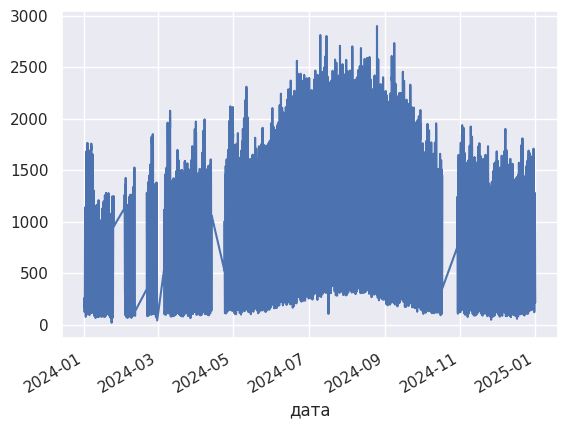

In [60]:
df['Общая интенсивность автомобилей']['Итого'].plot()

In [61]:
df_daily = df.resample('M').sum()

/tmp/ipykernel_25795/3776649264.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_daily = df.resample('M').sum()


/tmp/ipykernel_25795/824597157.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').sum()


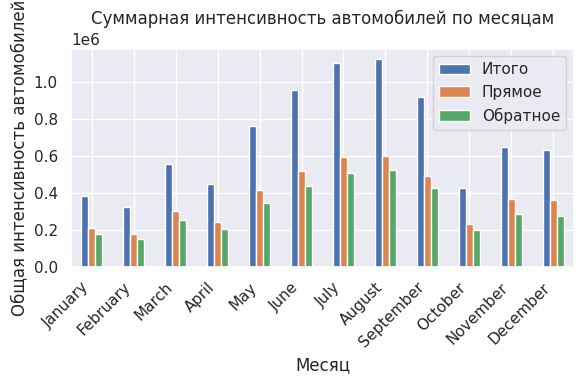

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Приводим индекс к datetime, если еще не сделано
df.index = pd.to_datetime(df.index)

# Агрегация по месяцам
df_monthly = df.resample('M').sum()

# Построение графика
fig, ax = plt.subplots(figsize=(6, 4))
df_monthly['Общая интенсивность автомобилей'].plot(kind='bar', ax=ax)

# Форматирование подписей по оси X — месяцы
ax.set_xticklabels(df_monthly.index.strftime('%B'), rotation=45, ha='right')

# Заголовки
ax.set_xlabel('Месяц')
ax.set_ylabel('Общая интенсивность автомобилей')
ax.set_title('Суммарная интенсивность автомобилей по месяцам')

plt.tight_layout()
plt.show()

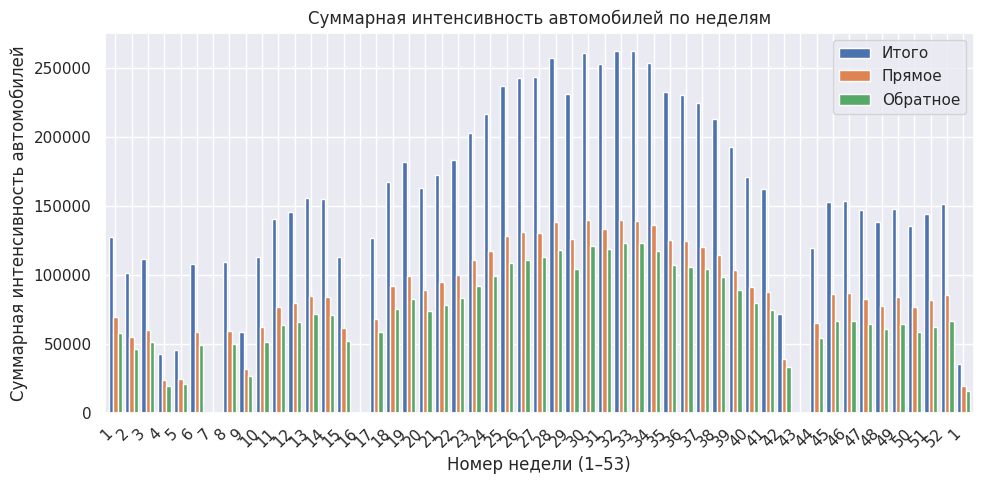

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Приводим индекс к datetime
df.index = pd.to_datetime(df.index)

# Агрегация по неделям
df_weekly = df.resample('W').sum()

# Получаем ISO-номер недели для каждой метки
week_numbers = df_weekly.index.isocalendar().week

# Построение графика с более толстыми столбцами
fig, ax = plt.subplots(figsize=(10, 5))
df_weekly['Общая интенсивность автомобилей'].plot(
    kind='bar',
    ax=ax,
    width=0.8
)

# Подписи оси X — просто номера недель
ax.set_xticklabels(
    week_numbers,
    rotation=45,
    ha='right'
)

# Заголовки
ax.set_xlabel('Номер недели (1–53)')
ax.set_ylabel('Суммарная интенсивность автомобилей')
ax.set_title('Суммарная интенсивность автомобилей по неделям')

plt.tight_layout()
plt.show()

In [64]:
df_weekly[4:9]

Общая интенсивность автомобилей                    \
                                     Итого   Прямое Обратное   
дата                                                           
2024-02-04                         45491.0  24307.0  21184.0   
2024-02-11                        107489.0  58299.0  49190.0   
2024-02-18                             0.0      0.0      0.0   
2024-02-25                        109480.0  59300.0  50180.0   
2024-03-03                         58392.0  31842.0  26550.0   

           Легковые (до 6 м)                   Малые груз. (6-9 м)          \
                       Итого   Прямое Обратное               Итого  Прямое   
дата                                                                         
2024-02-04           41255.0  21689.0  19566.0              1452.0   887.0   
2024-02-11           96746.0  51871.0  44875.0              3808.0  2148.0   
2024-02-18               0.0      0.0      0.0                 0.0     0.0   
2024-02-25          101227.0  54648.0  46579.0              2946.0  1623.0   
2024-03-03           52434.0  28471.0  23963.0              2023.0  1098.0   

                    Грузовые (9-13 м)  ... Автобусы                 Мотоциклы  \
           Обратное             Итого  ...    Итого Прямое Обратное     Итого   
дата                                   ...                                      
2024-02-04    565.0            1256.0  ...    163.0  104.0     59.0       0.0   
2024-02-11   1660.0            3125.0  ...    467.0  283.0    184.0       0.0   
2024-02-18      0.0               0.0  ...      0.0    0.0      0.0       0.0   
2024-02-25   1323.0            2358.0  ...    261.0  137.0    124.0       0.0   
2024-03-03    925.0            1758.0  ...    270.0  154.0    116.0       0.0   

                           Скорость, км/ч          Загрузка, %           
           Прямое Обратное         Прямое Обратное      Прямое Обратное  
дата                                                                     
2024-02-04    0.0      0.0         6256.0   6477.0       132.0    117.0  
2024-02-11    0.0      0.0        14939.0  15601.0       554.0    278.0  
2024-02-18    0.0      0.0            0.0      0.0         0.0      0.0  
2024-02-25    0.0      0.0        13050.0  13678.0       488.0    263.0  
2024-03-03    0.0      0.0         7507.0   8006.0       277.0    153.0  

[5 rows x 28 columns]

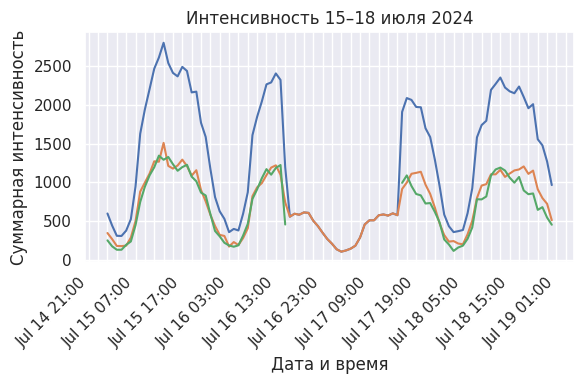

In [103]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

series = df.loc['2024-07-15':'2024-07-18']['Общая интенсивность автомобилей']

# Рисуем
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(series.index, series.values)

# Задаём локатор – допустим, метки каждые 2 часа
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Задаём форматтер для отображения часов и минут
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    label.set_visible(i % 5 == 0)
# Поворачиваем подписи и подписываем оси
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Дата и время')
ax.set_ylabel('Суммарная интенсивность')
ax.set_title('Интенсивность 15–18 июля 2024')

plt.tight_layout()
plt.show()

<Axes: xlabel='Дата и время'>

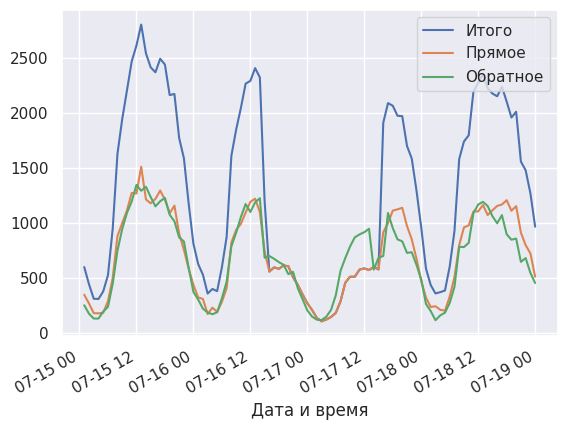

In [82]:
df_predicted.loc['2024-07-15':'2024-07-18']['Общая интенсивность автомобилей'].plot()

In [89]:
df_full = df.asfreq('H')

/tmp/ipykernel_25795/1066387277.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_full = df.asfreq('H')


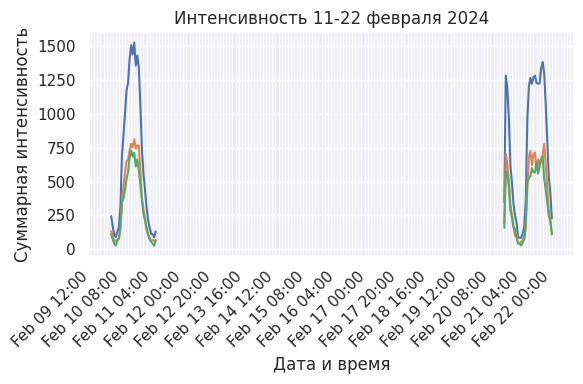

In [102]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

series = df_full.loc['2024-02-10':'2024-02-21']['Общая интенсивность автомобилей']

# Рисуем
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(series.index, series.values)

# Задаём локатор – допустим, метки каждые 2 часа
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Задаём форматтер для отображения часов и минут
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    label.set_visible(i % 10 == 0)
# Поворачиваем подписи и подписываем оси
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Дата и время')
ax.set_ylabel('Суммарная интенсивность')
ax.set_title('Интенсивность 11-22 февраля 2024')

plt.tight_layout()
plt.show()

In [124]:
slice_puid = df_full.loc['2024-07-10':'2024-07-17 15:59:59']['Общая интенсивность автомобилей']
known = slice_puid.dropna().reset_index()
x = known.index.values  # Индексы
y = known['Обратное'].values  # Известные значения
poly = np.polyfit(x, y, deg=10)
trend_func = np.poly1d(poly)

# # Заполняем пропущенные значения трендом
slice_puid['Trend_Polyfit'] = trend_func(range(len(slice_puid)))


<Axes: xlabel='Дата и время'>

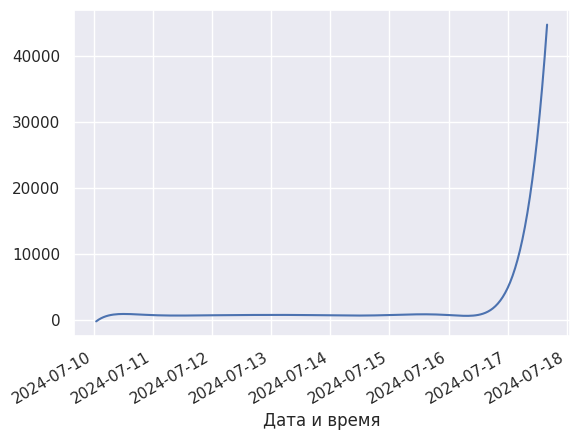

In [126]:
slice_puid['Trend_Polyfit'].plot()

In [127]:
slice_puid['ewm'] = slice_puid['Обратное'].ewm(
    span=20, adjust=False).mean()
# slice_puid2[['volume', 'ewm']][s1 - pd.Timedelta(hours=10):s1].plot()

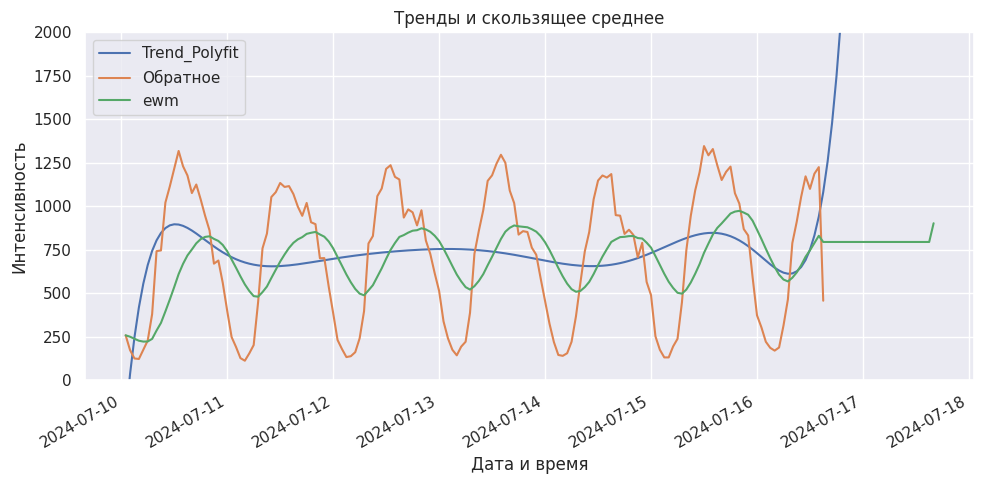

In [136]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Ваши три кривые на одном Axes
slice_puid[['Trend_Polyfit', 'Обратное', 'ewm']].plot(ax=ax)

# Задаём границы по вертикали: от 0 до 5000 (пример)
ax.set_ylim(0, 2000)

ax.set_xlabel('Дата и время')
ax.set_ylabel('Интенсивность')
ax.set_title('Тренды и скользящее среднее')

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

known['Обратное'].values

array([ 258.,  173.,  125.,  122.,  175.,  228.,  380.,  742.,  746.,
       1021., 1114., 1216., 1318., 1230., 1177., 1076., 1125., 1039.,
        945.,  861.,  670.,  688.,  559.,  399.,  248.,  191.,  127.,
        112.,  154.,  202.,  448.,  758.,  843., 1053., 1081., 1134.,
       1111., 1116., 1070.,  998.,  945., 1019.,  908.,  897.,  701.,
        702.,  537.,  386.,  231.,  179.,  133.,  138.,  161.,  241.,
        397.,  786.,  829., 1058., 1102., 1215., 1236., 1169., 1154.,
        935.,  982.,  965.,  890.,  977.,  803.,  726.,  615.,  513.,
        338.,  241.,  175.,  143.,  193.,  221.,  388.,  727.,  859.,
        978., 1146., 1178., 1245., 1296., 1250., 1090., 1018.,  837.,
        857.,  852.,  762.,  721.,  585.,  456.,  325.,  219.,  145.,
        140.,  155.,  221.,  368.,  560.,  741.,  852., 1040., 1148.,
       1177., 1165., 1185.,  949.,  946.,  841.,  865.,  835.,  706.,
        790.,  565.,  489.,  252.,  175.,  131.,  131.,  194.,  238.,
        448.,  748.,

In [144]:
eps = 10e-03
train = known['Обратное'].copy()
train = np.log(train.fillna(train.mean()).map(lambda x: max(x, 1)) + eps)

fit = ExponentialSmoothing(
    train,
    trend=None,
    seasonal='mul',
    seasonal_periods=24,
    damped_trend=False,
).fit()

In [155]:
len(slice_puid) - len(known)

24

In [166]:
np.exp(fit.forecast(len(slice_puid) - len(known))).values

array([810.46054388, 771.59636357, 727.00630656, 714.37380957,
       596.226273  , 590.88406719, 462.52794636, 351.85450095,
       232.36460419, 168.45042216, 123.96645059, 116.65875073,
       148.06974387, 199.64929032, 342.3964531 , 593.51422083,
       681.25220323, 820.36452632, 905.28188083, 958.97823162,
       985.74613757, 982.18883458, 836.08164222, 831.29945761])

In [175]:
slice_puid.loc[slice_puid['Обратное'].isna(), 'Обратное_заполненное'] = np.exp(
    fit.forecast(len(slice_puid) - len(known))).values

In [159]:
slice_puid['Обратное_заполненное'] = np.exp(
    fit.forecast(len(slice_puid) - len(known)))

In [182]:
slice_puid

,Итого,Прямое,Обратное,Полином,ewm,Экспоненциальное сглаживание Holt-Winter`s
Дата и время,,,,,,
2024-07-10 00:59:59,558.0,300.0,258.0,-222.379162,258.000000,NaN
2024-07-10 01:59:59,430.0,257.0,173.0,35.811820,249.904762,NaN
2024-07-10 02:59:59,278.0,153.0,125.0,247.377792,238.009070,NaN
2024-07-10 03:59:59,294.0,172.0,122.0,418.612309,226.960587,NaN
2024-07-10 04:59:59,371.0,196.0,175.0,555.144299,222.011960,NaN
...,...,...,...,...,...,...
2024-07-17 11:59:59,587.0,587.0,NaN,27458.324792,794.717505,985.746138
2024-07-17 12:59:59,572.0,572.0,NaN,31127.673699,794.717505,982.188835
2024-07-17 13:59:59,601.0,601.0,NaN,35199.547997,794.717505,836.081642


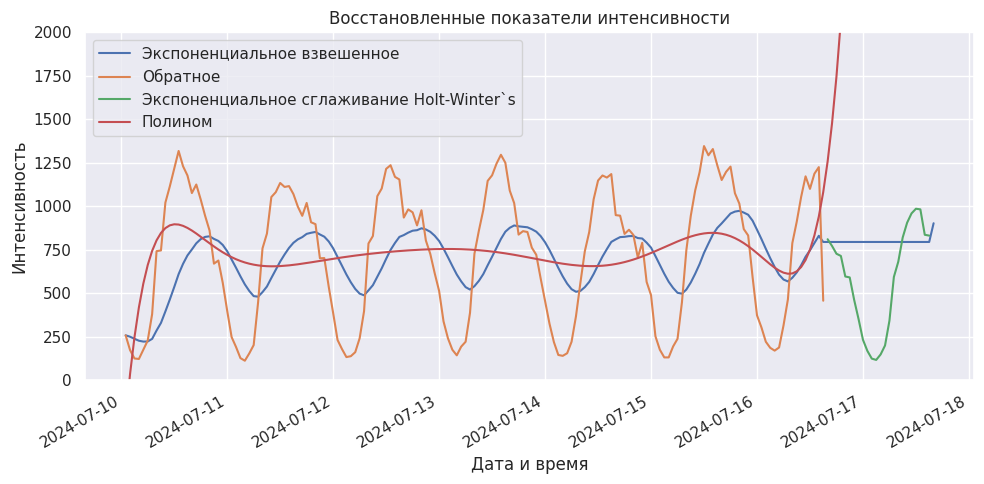

In [185]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Ваши три кривые на одном Axes
slice_puid[['Экспоненциальное взвешенное', 'Обратное',
            'Экспоненциальное сглаживание Holt-Winter`s', 'Полином']].plot(ax=ax)

# Задаём границы по вертикали: от 0 до 5000 (пример)
ax.set_ylim(0, 2000)

ax.set_xlabel('Дата и время')
ax.set_ylabel('Интенсивность')
ax.set_title('Восстановленные показатели интенсивности')

plt.tight_layout()
plt.show()

In [183]:
slice_puid.rename(
    columns={'ewm': 'Экспоненциальное взвешенное'},
    inplace=True
)